##Libraries


In [95]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt


### Import Data

In [96]:
data= pd.read_csv("/content/drive/MyDrive/Machine Learning/CH-512/Project/Table - IN_Table.csv.csv")
data

,IN1,IN2,IN3,IN4,IN5,Out1,Out2
0,0.077744,0.795565,-0.665503,0.879321,0.134419,-0.122686,0.123661
1,0.080313,0.824595,-0.655447,0.875636,0.134941,-0.122686,0.123661
2,0.087355,0.776258,-0.650550,0.884105,0.132452,-0.026857,0.123661
3,0.091774,0.739149,-0.644934,0.892043,0.131287,-0.026857,0.251010
4,0.091166,0.761332,-0.648654,0.892752,0.136788,-0.026857,0.251010
...,...,...,...,...,...,...,...
14396,-2.371841,-1.399878,-2.594168,-0.861832,-1.607387,-2.039274,-1.531870
14397,-2.378745,-1.407683,-2.601522,-0.871577,-1.604817,-2.039274,-1.531870
14398,-2.385070,-1.388787,-2.606594,-0.880330,-1.579605,-1.943445,-1.659219
14399,-2.386119,-1.372492,-2.615738,-0.886744,-1.556761,-1.943445,-1.659219


## Visualizing the Data


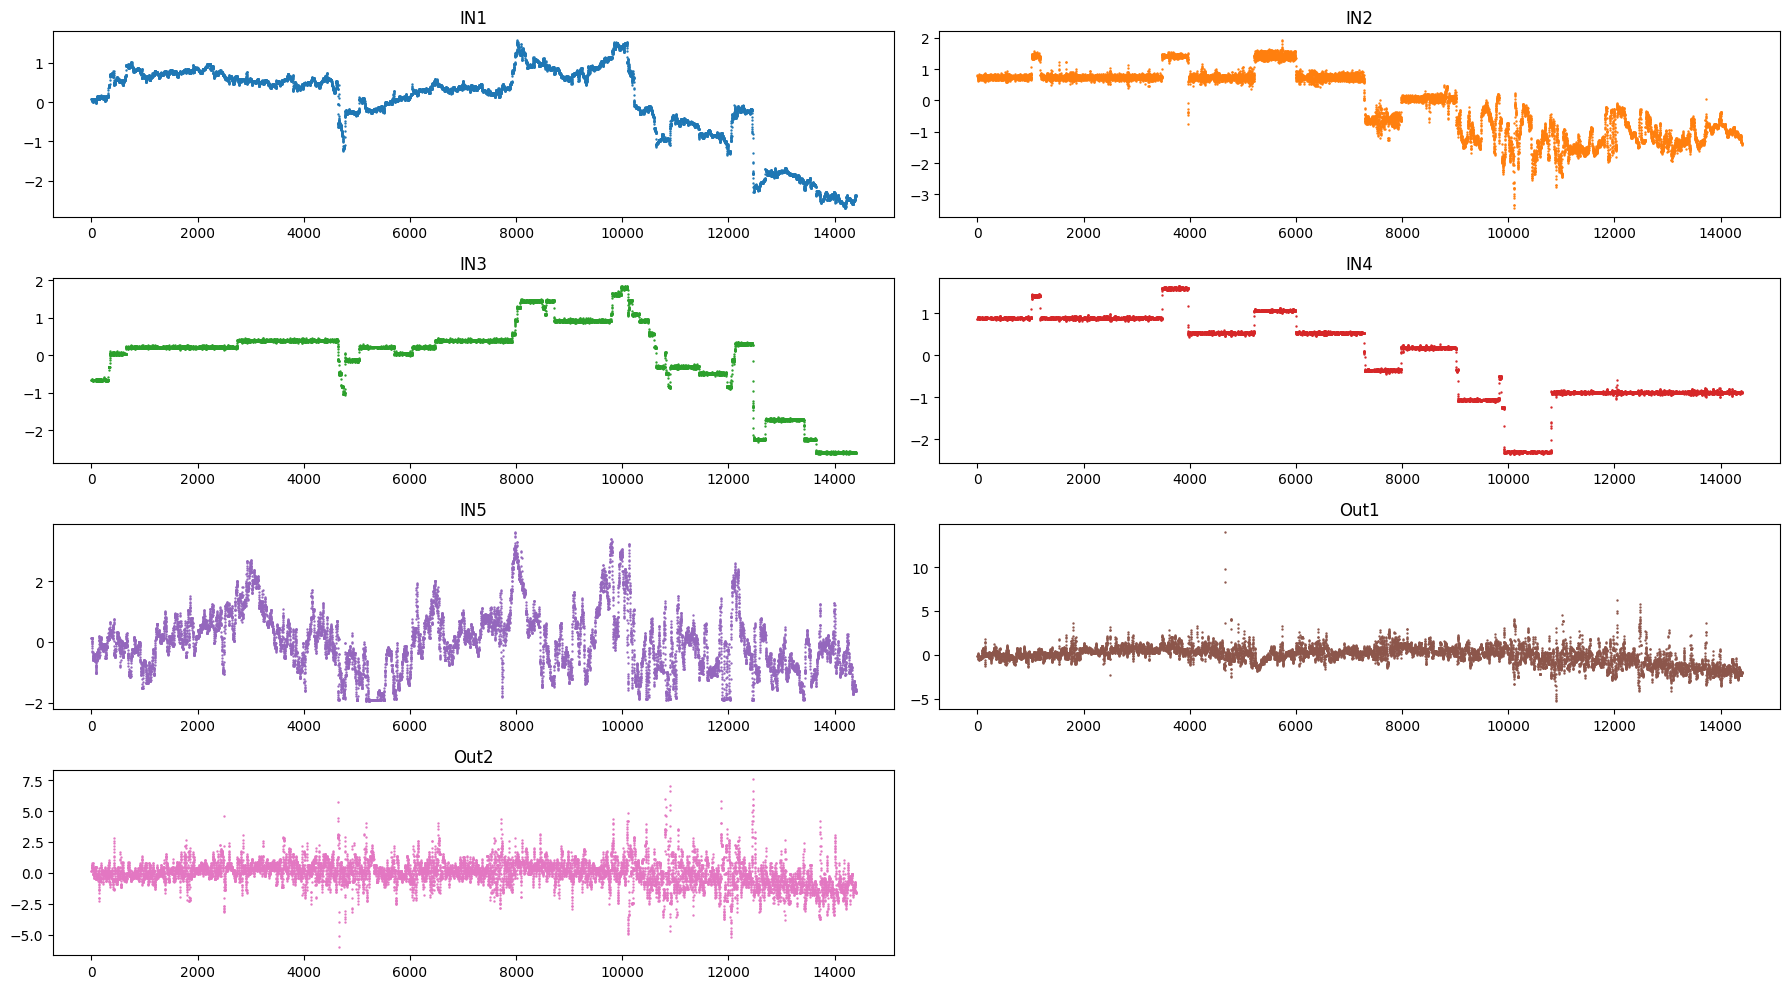

In [97]:
plt.figure(figsize=(18, 10))

num_cols = 7
num_rows = (num_cols + 1) // 2  # To handle odd number of columns

for i, col in enumerate(data.columns, start=1):
    plt.subplot(num_rows, 2, i)
    plt.scatter(data.index, data[col], marker='.', color='C{}'.format(i-1),s=2 )
    plt.title(col)

plt.tight_layout()
plt.show()

#Linear Regression

In [98]:
x  = data[['IN1','IN2','IN5']]
y1 = data[['Out1']]
y2 = data[['Out2']]

### Splitting the dataset into the Training set and Test set

In [99]:
from sklearn.model_selection import train_test_split
x_train, x_test, y1_train, y1_test = train_test_split(x, y1, test_size = 0.2, random_state = 0)

### Training the Multiple Linear Regression model on the Training set

In [100]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y1_train)

LinearRegression()

## Predicting the Test set results

In [101]:
# Assuming y1_test is a DataFrame, extract its values
y1_test_values = y1_test.values

# Now you can use np.concatenate with reshaping
y1_pred = regressor.predict(x_test)
np.set_printoptions(precision=2)
print(np.concatenate((y1_pred.reshape(len(y1_pred),1), y1_test_values.reshape(len(y1_test_values),1)),1))


[[0.16 0.45]
 [0.48 1.03]
 [0.61 0.26]
 ...
 [0.64 0.84]
 [0.27 1.7 ]
 [0.4  0.36]]


## Evaluating the Model Performance

In [102]:
from sklearn.metrics import r2_score
r2_score(y1_test, y1_pred)

0.3896068458237244